# 07 — Framing and Bias

> **"The same data can tell opposite stories depending on how you frame it."**

---

Visualization không bao giờ trung lập hoàn toàn.
Mọi lựa chọn thiết kế — trục bắt đầu từ đâu, khoảng thời gian nào được chọn,
đơn vị nào được dùng — đều là một hành động **framing**.

Framing tốt = làm rõ insight thật sự.
Framing xấu (dù vô tình hay cố ý) = misleading visualization.

Notebook này không dạy cách tạo misleading charts —
nó dạy cách **nhận ra** chúng để không bị đánh lừa, và không vô tình tạo ra chúng.

### Nội dung notebook này:

1. **Truncated Y-Axis** — Phóng đại thay đổi nhỏ
2. **Cherry-Picking Time Window** — Chọn khoảng thời gian có lợi
3. **Percentage vs Absolute** — Cùng số, khác câu chuyện
4. **Dual Axis Manipulation** — Tạo correlation giả
5. **Cumulative vs Period** — Che giấu sự chậm lại
6. **Sample Size Blindness** — Tỷ lệ % mà không nói n
7. **Misleading Baseline** — Area chart không từ 0
8. **Simpson's Paradox** — Trend bị đảo chiều khi aggregate
9. **Honest Chart Checklist**

## Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import format_percent, format_thousands, set_tick_style
from vizint.annotation import add_note, add_caption, annotate_with_arrow
from vizint.context import add_reference_line
from vizint.styling import categorical_colors
from vizint.styling.typography import TITLE_SIZE, CAPTION_SIZE

np.random.seed(42)

# ── Helper: side-by-side bad vs good ─────────────────────────────
def make_pair(title_bad, title_good, figsize=(14, 4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, facecolor='white')
    for ax, title, tag, color in zip(
        axes,
        [title_bad, title_good],
        ['Misleading', 'Honest'],
        ['#DC2626', '#16A34A'],
    ):
        ax.set_title(f'{tag}\n{title}',
                     loc='left', fontsize=9, fontweight='bold', color=color)
        despine(ax); set_grid(ax)
    return fig, axes

print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Một tập dữ liệu dùng xuyên suốt: **monthly revenue 48 tháng** với tăng trưởng chậm nhưng đều.

In [13]:
T = 48
months = np.arange(T)

# Slow but steady growth
revenue   = 1000 + months * 2.5 + np.random.randn(T) * 8
product_a = 500  + months * 3.0 + np.random.randn(T) * 10   # revenue $K
product_b = 80   + months * 0.4 + np.random.randn(T) * 2    # units sold

print(f'Revenue  : {T} months, range [{revenue.min():.0f}, {revenue.max():.0f}]')
print(f'Product A: [{product_a.min():.0f}, {product_a.max():.0f}] $K')
print(f'Product B: [{product_b.min():.0f}, {product_b.max():.0f}] units')

Revenue  : 48 months, range [1001, 1126]
Product A: [485, 639] $K
Product B: [79, 101] units


## 1. Truncated Y-Axis

Kỹ thuật: bắt đầu trục y từ giá trị khác 0, thường gần min của data.
Mục tiêu: phóng đại biến động nhỏ để thấy rõ thay đổi.

Hiệu ứng:

- biến đổi nhỏ trông như biến đổi lớn
- slope trông dốc hơn
- volatility bị phóng đại
- perception về magnitude bị sai lệch

---

### 1.1 Khi truncated axis có thể chấp nhận

Dùng được khi mục tiêu là **so sánh thay đổi**, không phải magnitude:

- line chart time series
- temperature change
- growth rate
- spread / deviation nhỏ
- KPI dao động trong range hẹp

Trong các trường hợp này, zero không có ý nghĩa tham chiếu.

---

### 1.2 Khi không nên dùng truncated axis

Không nên dùng khi:

- người xem cần so sánh magnitude
- baseline 0 có ý nghĩa
- muốn đánh giá tỷ lệ thực

Truncated axis dễ gây hiểu nhầm về scale.

---

### 1.3 Bar chart phải bắt đầu từ 0

Bar chart encode magnitude bằng **chiều dài**.

Nếu không bắt đầu từ 0:

- chiều dài bị bóp méo
- so sánh sai lệch
- perception không chính xác

Vì vậy bar chart luôn bắt đầu từ 0.

---

### 1.4 Area chart cũng phải bắt đầu từ 0

Area chart encode magnitude bằng **diện tích**.

Nếu truncate:

- diện tích bị bóp méo
- visual weight sai
- tổng bị hiểu sai

Do đó area chart cũng cần baseline 0.

---

### 1.5 Best practices

Nếu dùng truncated axis:

- annotate clearly
- thêm axis break
- highlight scale
- dùng cho line chart thôi

Tránh dùng cho:

- bar chart
- stacked area
- waterfall
- contribution chart

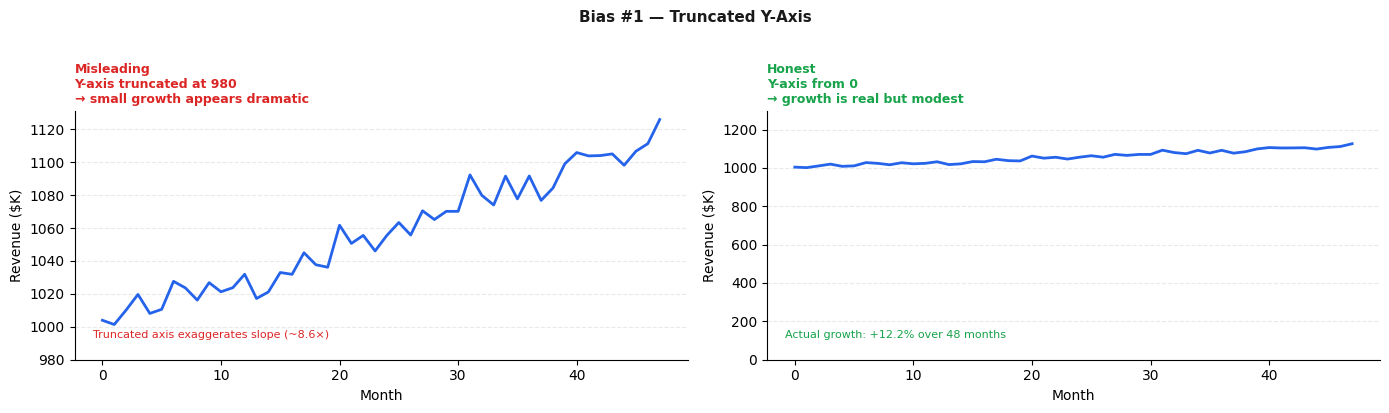

In [23]:
fig, axes = make_pair(
    'Y-axis truncated at 980\n→ small growth appears dramatic',
    'Y-axis from 0\n→ growth is real but modest'
)

# Misleading: truncated axis
ax = axes[0]
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(980, revenue.max() + 5)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')

# quantify visual exaggeration via axis range
truncated_range = (revenue.max() + 5) - 980
full_range = (revenue.max() * 1.15) - 0
exaggeration = full_range / truncated_range

add_note(
    ax,
    f'Truncated axis exaggerates slope (~{exaggeration:.1f}×)',
    x=0.03, y=0.12,
    color='#DC2626',
    fontsize=8
)

# Honest: from zero
ax = axes[1]
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(0, revenue.max() * 1.15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')

actual_pct = (revenue[-1] - revenue[0]) / revenue[0] * 100
add_note(
    ax,
    f'Actual growth: +{actual_pct:.1f}% over {T} months',
    x=0.03, y=0.12,
    color='#16A34A',
    fontsize=8
)

fig.suptitle(
    'Bias #1 — Truncated Y-Axis',
    fontsize=11,
    fontweight='bold',
    color='#1a1a1a',
    y=1.02
)

plt.tight_layout()
plt.show()

## Truncated Y-Axis — Visualization Notes

Biểu đồ đặt **truncated y-axis** cạnh **zero-based axis** để cho thấy
cách scale trục y làm thay đổi perception về tăng trưởng.

### Truncated axis phóng đại biến động
Chart bên trái bắt đầu trục y gần min:

- range trục nhỏ
- slope trông dốc hơn
- biến động nhỏ trông lớn

Tăng trưởng nhẹ trở nên có vẻ dramatic.

### Zero-based axis cho magnitude thực
Chart bên phải bắt đầu từ 0:

- giữ đúng tỷ lệ
- slope nhẹ hơn
- growth nhìn khiêm tốn hơn

Phản ánh magnitude thực của thay đổi.

### Cùng data nhưng perception khác
Hai chart dùng cùng series:

- chart trái → growth trông mạnh
- chart phải → growth nhỏ

Sự khác biệt chỉ do y-axis scale.

### Line slope bị ảnh hưởng bởi axis range
Slope phụ thuộc:

- y-axis range
- không chỉ data change

Range nhỏ → slope dốc
Range lớn → slope phẳng

### Side-by-side layout làm rõ bias
Đặt cạnh nhau giúp:

- so sánh trực tiếp
- thấy distortion
- hiểu impact của axis choice

Minh họa bias hiệu quả.

### Khi truncated axis gây hiểu nhầm
Truncated axis:

- exaggerate growth
- exaggerate volatility
- làm thay đổi narrative

Cần annotate rõ khi sử dụng.

## 2. Cherry-Picking Time Window

Kỹ thuật: chọn khoảng thời gian bắt đầu hoặc kết thúc có lợi cho narrative.
Cùng một dữ liệu nhưng window khác nhau có thể tạo kết luận khác nhau.

Cherry-picking thường xảy ra khi:

- chọn đáy làm điểm bắt đầu để phóng đại tăng trưởng
- chọn đỉnh làm điểm bắt đầu để phóng đại suy giảm
- cắt bỏ giai đoạn bất lợi
- chỉ hiển thị đoạn ngắn thuận lợi

---

### 2.1 Window selection thay đổi narrative

Time series phụ thuộc mạnh vào:

- start point
- end point
- window length

Thay đổi window có thể biến:

- flat trend → strong growth
- recovery → decline
- volatility → stability

---

### 2.2 Short window dễ gây hiểu nhầm

Window ngắn:

- nhạy với noise
- dễ chọn điểm cực trị
- exaggerate slope

Dẫn đến kết luận không đại diện.

---

### 2.3 Long window cung cấp context

Window dài hơn giúp:

- thấy full cycle
- thấy regime change
- thấy trend thật
- tránh bias điểm đầu/cuối

Context làm giảm cherry-picking.

---

### 2.4 Dấu hiệu cherry-picking

Một chart có thể bị cherry-pick nếu:

- bắt đầu đúng tại local minimum
- kết thúc tại local maximum
- bỏ qua phần trước đó
- không rõ time span

Các dấu hiệu này thường tạo slope “đẹp”.

---

### 2.5 Best practices

Để tránh cherry-picking:

- hiển thị full history khi có thể
- annotate window rõ ràng
- thêm zoomed inset thay vì cắt data
- so sánh nhiều window khác nhau

Giữ context giúp chart trung thực hơn.

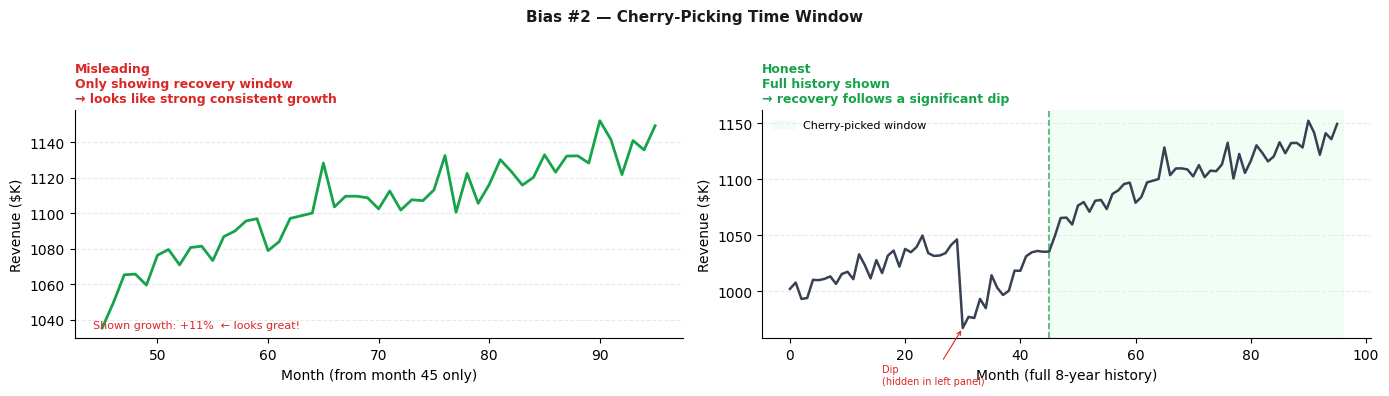

In [15]:
# Longer series with a dip then recovery
T_long = 96
m_long = np.arange(T_long)
rev_long = (
    1000
    + m_long * 1.5
    + np.where((m_long >= 30) & (m_long <= 50), -80 + (m_long - 30) * 4, 0)
    + np.random.randn(T_long) * 8
)
cherry_start = 45   # only show recovery part

fig, axes = make_pair(
    'Only showing recovery window\n→ looks like strong consistent growth',
    'Full history shown\n→ recovery follows a significant dip'
)

# Misleading: cherry-picked
ax = axes[0]
ax.plot(m_long[cherry_start:], rev_long[cherry_start:],
        color='#16A34A', linewidth=2.0)
ax.set_xlabel('Month (from month 45 only)')
ax.set_ylabel('Revenue ($K)')
cherry_growth = (rev_long[-1] - rev_long[cherry_start]) / rev_long[cherry_start] * 100
add_note(ax, f'Shown growth: +{cherry_growth:.0f}%  ← looks great!',
         x=0.03, y=0.08, color='#DC2626', fontsize=8)

# Honest: full history
ax = axes[1]
ax.plot(m_long, rev_long, color='#374151', linewidth=1.8)
ax.axvspan(cherry_start, T_long, color='#DCFCE7', alpha=0.35,
           label='Cherry-picked window')
ax.axvline(cherry_start, color='#16A34A', linewidth=1.2, linestyle='--', alpha=0.8)
dip_idx = int(np.argmin(rev_long[30:55])) + 30
ax.annotate('Dip\n(hidden in left panel)',
            xy=(dip_idx, rev_long[dip_idx]),
            xytext=(dip_idx - 14, rev_long[dip_idx] - 50),
            fontsize=7, color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))
ax.set_xlabel('Month (full 8-year history)')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)

fig.suptitle('Bias #2 — Cherry-Picking Time Window',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Cherry-Picking Time Window — Visualization Notes

Biểu đồ đặt **zoomed recovery window** cạnh **full history**
để cho thấy cách chọn time window làm thay đổi narrative.

### Zoomed window làm trend trông mạnh hơn
Chart bên trái chỉ hiển thị giai đoạn recovery:

- bắt đầu sau điểm giảm mạnh
- trend nhìn như tăng đều
- volatility trước đó bị ẩn

Tạo cảm giác tăng trưởng ổn định.

### Full history cung cấp context
Chart bên phải hiển thị toàn bộ series:

- thấy dip lớn trước recovery
- growth chỉ là rebound
- trend tổng thể kém ấn tượng hơn

Context thay đổi interpretation.

### Cherry-picked region được highlight
Vùng shaded trong chart phải:

- chính là window chart trái
- đặt trong full history
- cho thấy phần bị cắt bỏ

Giúp phát hiện cherry-picking trực quan.

### Start point ảnh hưởng narrative
Bắt đầu tại đáy:

- slope trông dốc
- growth trông mạnh
- narrative tích cực

Bắt đầu trước đó:

- thấy decline trước
- recovery bớt ấn tượng

### Side-by-side layout làm rõ bias
Hai chart cạnh nhau:

- cùng data
- khác window
- khác kết luận

Minh họa cherry-picking rõ ràng.

### Zoom vs context
Zoomed window:

- tốt để phân tích chi tiết
- nhưng dễ gây bias

Full history:

- cung cấp context
- tránh hiểu sai trend

## 3. Percentage vs Absolute

Kỹ thuật: chọn đơn vị hiển thị (absolute hoặc percentage)
để tạo ấn tượng mạnh hơn về thay đổi.

Cùng một dữ liệu nhưng:

- percentage có thể phóng đại thay đổi nhỏ
- absolute có thể phóng đại thay đổi lớn
- per-capita có thể đảo chiều kết luận

---

### 3.1 Percentage phóng đại base nhỏ

Khi baseline nhỏ:

- thay đổi nhỏ → % lớn
- growth trông dramatic
- magnitude thực tế nhỏ

Percentage dễ gây hiểu nhầm khi base nhỏ.

---

### 3.2 Absolute phóng đại base lớn

Khi baseline lớn:

- thay đổi lớn về số tuyệt đối
- nhưng % nhỏ
- impact tương đối thấp

Absolute dễ gây ấn tượng mạnh dù change nhỏ.

---

### 3.3 Percentage vs absolute kể hai câu chuyện

Percentage nhấn mạnh:

- tốc độ tăng trưởng
- relative change
- growth rate

Absolute nhấn mạnh:

- magnitude
- quy mô thực
- impact tổng

Hai cách thể hiện khác narrative.

---

### 3.4 Khi chỉ dùng một metric dễ gây bias

Chỉ percentage:

- exaggerate small numbers
- ẩn magnitude thực

Chỉ absolute:

- exaggerate large scale
- ẩn relative change

Hiển thị một loại dễ tạo misleading impression.

---

### 3.5 Best practice: hiển thị cả hai

Khi cả hai đều có ý nghĩa:

- label absolute
- annotate percentage
- hoặc dùng secondary axis
- hoặc side-by-side chart

Giúp người xem có đầy đủ context.

---

### 3.6 Khi nên dùng từng loại

Dùng percentage khi:

- so sánh growth rate
- so sánh nhóm khác scale
- phân tích relative change

Dùng absolute khi:

- quan tâm magnitude
- đánh giá impact thực
- báo cáo tổng quy mô

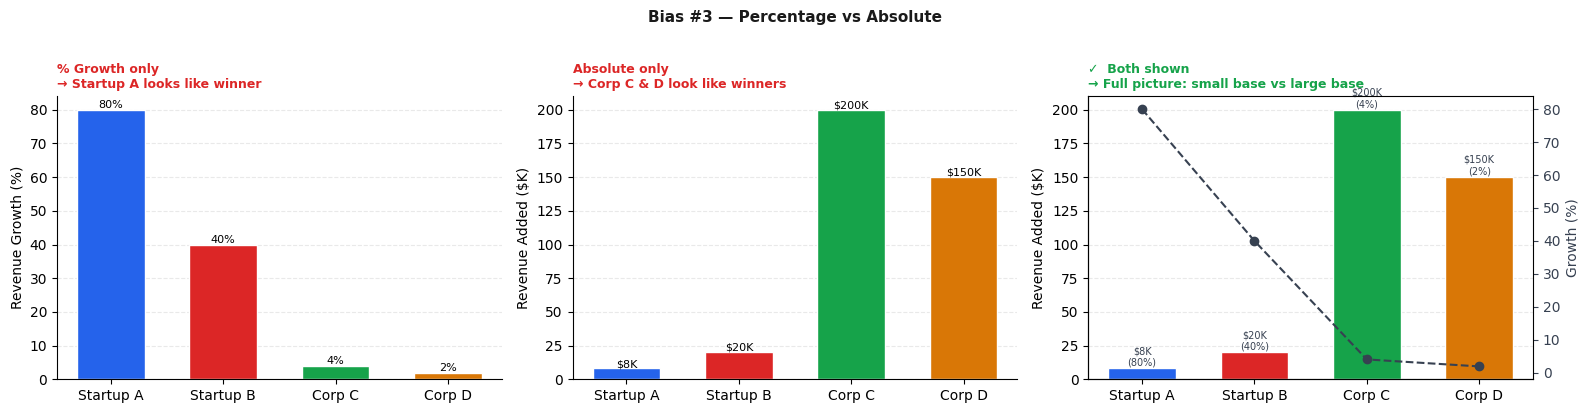

In [16]:
companies  = ['Startup A', 'Startup B', 'Corp C', 'Corp D']
base_rev   = np.array([10,   50,   5000,  8000])   # $K
growth_abs = np.array([8,    20,   200,   150])     # $K added
growth_pct = growth_abs / base_rev * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')
colors4 = categorical_colors(4)

# Panel 1: % only
ax = axes[0]
bars = ax.bar(companies, growth_pct, color=colors4, edgecolor='white', width=0.6)
for bar, v in zip(bars, growth_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_ylabel('Revenue Growth (%)'); ax.set_title(
    '% Growth only\n→ Startup A looks like winner',
    loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Panel 2: absolute only
ax = axes[1]
bars = ax.bar(companies, growth_abs, color=colors4, edgecolor='white', width=0.6)
for bar, v in zip(bars, growth_abs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, f'${v}K', ha='center', fontsize=8)
ax.set_ylabel('Revenue Added ($K)'); ax.set_title(
    'Absolute only\n→ Corp C & D look like winners',
    loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Panel 3: both
ax = axes[2]
x = np.arange(len(companies))
ax.bar(x, growth_abs, color=colors4, edgecolor='white', width=0.6)
ax2 = ax.twinx()
ax2.plot(x, growth_pct, 'o--', color='#374151', linewidth=1.5, markersize=6)
ax2.set_ylabel('Growth (%)', color='#374151')
ax2.tick_params(colors='#374151')
ax.set_xticks(x); ax.set_xticklabels(companies)
for i, (a, p) in enumerate(zip(growth_abs, growth_pct)):
    ax.text(i, a + 2, f'${a}K\n({p:.0f}%)', ha='center', fontsize=7, color='#374151')
ax.set_ylabel('Revenue Added ($K)'); ax.set_title(
    '✓  Both shown\n→ Full picture: small base vs large base',
    loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #3 — Percentage vs Absolute',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Percentage vs Absolute — Visualization Notes

Ba chart đặt cạnh nhau để cho thấy **percentage** và **absolute**
có thể dẫn đến kết luận hoàn toàn khác nhau.

### Percentage-only làm nổi bật base nhỏ
Chart bên trái dùng growth %:

- startup nhỏ có % cao
- corp lớn có % thấp
- startup trông như winner

Percentage nhấn mạnh relative growth.

### Absolute-only làm nổi bật base lớn
Chart giữa dùng revenue added:

- corp lớn thêm nhiều tuyệt đối
- startup thêm ít
- corp trông như winner

Absolute nhấn mạnh magnitude.

### Hai metric kể hai câu chuyện khác nhau
Percentage:

- ai tăng nhanh hơn
- growth rate
- relative performance

Absolute:

- ai tạo nhiều giá trị hơn
- impact thực
- scale effect

Kết luận thay đổi theo metric.

### Combined chart cung cấp full context
Chart bên phải hiển thị:

- bar = absolute
- line = percentage
- dual axis

Cho thấy base nhỏ vs base lớn.

### Small base vs large base effect
Startup:

- % lớn
- absolute nhỏ

Corporation:

- % nhỏ
- absolute lớn

Cần cả hai để đánh giá đúng.

### Khi chỉ dùng một metric dễ gây bias
Chỉ percentage:

- exaggerate startup
- ẩn magnitude

Chỉ absolute:

- favor corp lớn
- ẩn growth rate

Hiển thị cả hai giảm bias.

## 4. Dual Axis Manipulation

Dual axis cho phép scale hai trục y độc lập,
có thể tạo cảm giác correlation ngay cả khi hai series không liên quan.

Bằng cách điều chỉnh range của mỗi axis:

- hai đường có thể trông cùng hướng
- peak có thể trông aligned
- slope có thể trông tương tự

Correlation trở thành artifact của scale.

---

### 4.1 Independent scaling gây correlation giả

Dual axis cho phép:

- trục trái scale nhỏ
- trục phải scale lớn
- hoặc ngược lại

Chỉ cần thay đổi range, hai series có thể:

- trông correlated
- trông diverging
- trông lagging

Mà không đổi data.

---

### 4.2 Line overlap gây hiểu nhầm

Khi hai line:

- nằm gần nhau
- có slope giống nhau
- có turning point gần

Người xem dễ suy ra causal relationship.

Dual axis làm tăng rủi ro này.

---

### 4.3 Axis range quyết định perception

Correlation trong dual axis phụ thuộc:

- min / max của axis trái
- min / max của axis phải
- aspect ratio chart

Thay đổi scale → thay đổi perceived relationship.

---

### 4.4 Khi dual axis có thể chấp nhận

Chỉ nên dùng khi:

- hai series khác đơn vị
- cần overlay trend
- correlation là secondary

Ví dụ:

- revenue vs margin %
- temperature vs demand
- price vs volume

Phải label rõ ràng.

---

### 4.5 Thay thế tốt hơn: index về base 100

Normalize cả hai series:

- base = 100 tại thời điểm đầu
- cùng axis
- so sánh change trực tiếp

Giữ:

- slope thật
- correlation thật
- không phụ thuộc scale.

---

### 4.6 Best practices

Nếu buộc dùng dual axis:

- color match axis với line
- label rõ đơn vị
- tránh align artificially
- annotate caution

Tốt hơn:

- normalize base 100
- dùng small multiples
- dùng separate panels

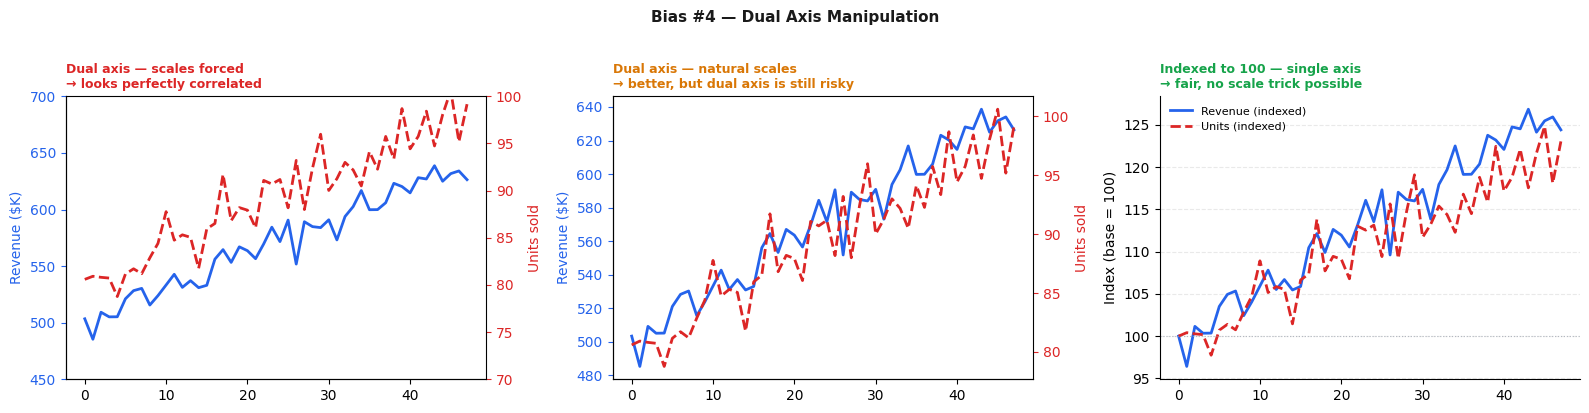

In [17]:
from vizint.comparison.relative import index_to_base

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

# Misleading: forced scale to fake correlation
ax = axes[0]
ax2 = ax.twinx()
ax.plot(months, product_a, color='#2563EB', linewidth=2.0, label='Revenue ($K)')
ax2.plot(months, product_b, color='#DC2626', linewidth=2.0, linestyle='--', label='Units')
ax.set_ylim(450, 700); ax2.set_ylim(70, 100)   # manually aligned to look correlated
ax.set_ylabel('Revenue ($K)', color='#2563EB')
ax2.set_ylabel('Units sold', color='#DC2626')
ax.tick_params(axis='y', colors='#2563EB')
ax2.tick_params(axis='y', colors='#DC2626')
ax.set_title('Dual axis — scales forced\n→ looks perfectly correlated',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax)

# Better dual axis: natural scales
ax = axes[1]
ax2 = ax.twinx()
ax.plot(months, product_a, color='#2563EB', linewidth=2.0)
ax2.plot(months, product_b, color='#DC2626', linewidth=2.0, linestyle='--')
ax.set_ylabel('Revenue ($K)', color='#2563EB')
ax2.set_ylabel('Units sold', color='#DC2626')
ax.tick_params(axis='y', colors='#2563EB')
ax2.tick_params(axis='y', colors='#DC2626')
ax.set_title('Dual axis — natural scales\n→ better, but dual axis is still risky',
             loc='left', fontsize=9, fontweight='bold', color='#D97706')
despine(ax)

# Best: indexed single axis
ax = axes[2]
a_idx = index_to_base(product_a, 0, 100)
b_idx = index_to_base(product_b, 0, 100)
ax.plot(months, a_idx, color='#2563EB', linewidth=2.0, label='Revenue (indexed)')
ax.plot(months, b_idx, color='#DC2626', linewidth=2.0, linestyle='--', label='Units (indexed)')
ax.axhline(100, color='#9CA3AF', linewidth=0.8, linestyle=':', alpha=0.7)
ax.set_ylabel('Index (base = 100)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('Indexed to 100 — single axis\n→ fair, no scale trick possible',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #4 — Dual Axis Manipulation',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Dual Axis Manipulation — Visualization Notes

Ba chart minh họa cách **dual axis** có thể tạo correlation giả
và cách **index về 100** loại bỏ bias này.

### Forced scaling tạo correlation hoàn hảo
Chart bên trái dùng dual axis với scale bị ép:

- hai line gần như chồng nhau
- turning point trùng nhau
- trông như correlated mạnh

Correlation chỉ do axis scaling.

### Natural dual axis vẫn gây rủi ro
Chart giữa dùng scale tự nhiên hơn:

- hai line không còn trùng
- nhưng vẫn trông liên quan
- correlation vẫn dễ bị suy diễn

Dual axis luôn tiềm ẩn bias.

### Indexed về 100 loại bỏ scale bias
Chart bên phải:

- normalize base = 100
- single axis
- slope phản ánh change thật

Không thể ép correlation bằng scale.

### Dual axis làm mờ magnitude thật
Với dual axis:

- mỗi line có scale riêng
- slope không so sánh được
- khoảng cách không có ý nghĩa

Người xem dễ hiểu sai relationship.

### Single axis giữ so sánh công bằng
Index về 100:

- cùng baseline
- cùng scale
- so sánh change trực tiếp

Correlation nếu có là thật.

### So sánh ba cách thể hiện

Forced dual axis:

- correlation giả
- misleading

Natural dual axis:

- ít bias hơn
- vẫn risky

Indexed single axis:

- scale nhất quán
- fair comparison

## 5. Cumulative vs Period

Cumulative chart cộng dồn theo thời gian nên luôn đi lên,
ngay cả khi tăng trưởng đang chậm lại hoặc giảm.

Điều này có thể che giấu:

- slowdown
- negative growth
- volatility
- turning points

---

### 5.1 Cumulative luôn tạo impression tăng trưởng

Cumulative:

- đường luôn đi lên
- slope chỉ thay đổi nhẹ
- downturn khó nhận thấy

Ngay cả khi period growth âm, cumulative vẫn tăng.

---

### 5.2 Period chart hiển thị momentum thật

Period values (month / quarter):

- có thể tăng hoặc giảm
- thấy acceleration
- thấy deceleration
- thấy turning point

Phù hợp phân tích dynamics.

---

### 5.3 Cumulative che giấu slowdown

Khi growth giảm:

- cumulative vẫn tăng
- chỉ slope giảm nhẹ
- khó nhận ra slowdown

Period chart sẽ hiển thị rõ.

---

### 5.4 Hai chart trả lời câu hỏi khác nhau

Cumulative:

- tổng bao nhiêu
- progress tới đâu
- size theo thời gian

Period:

- tăng bao nhiêu mỗi kỳ
- growth đang nhanh hay chậm
- momentum thay đổi

Không nên dùng thay thế nhau.

---

### 5.5 Khi nên dùng cumulative

Cumulative phù hợp:

- total users
- lifetime revenue
- cumulative sales
- cumulative cases

Khi tổng mới quan trọng.

---

### 5.6 Khi nên dùng period

Period chart cần khi:

- phân tích growth
- theo dõi momentum
- phát hiện slowdown
- phát hiện decline

Dùng để hiểu change theo thời gian.

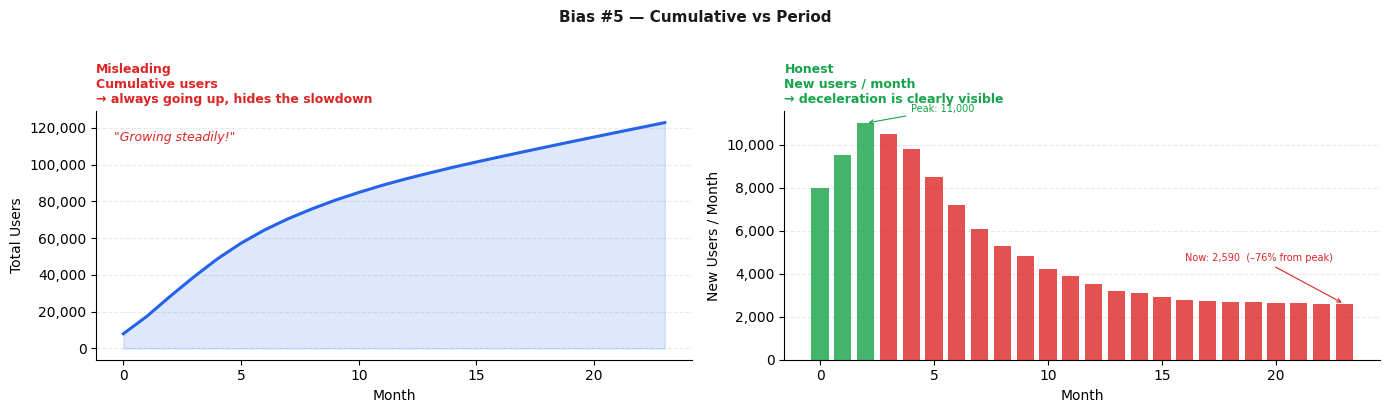

In [18]:
new_users = np.array([
    8000, 9500, 11000, 10500, 9800, 8500,
    7200, 6100, 5300,  4800,  4200, 3900,
    3500, 3200, 3100,  2900,  2800, 2750,
    2700, 2680, 2650,  2630,  2610, 2590,
])
cum_users = np.cumsum(new_users)
m24 = np.arange(len(new_users))

fig, axes = make_pair(
    'Cumulative users\n→ always going up, hides the slowdown',
    'New users / month\n→ deceleration is clearly visible'
)

# Misleading: cumulative
ax = axes[0]
ax.fill_between(m24, cum_users, color='#2563EB', alpha=0.15)
ax.plot(m24, cum_users, color='#2563EB', linewidth=2.2)
ax.set_xlabel('Month'); ax.set_ylabel('Total Users')
format_thousands(ax, 'y')
add_note(ax, '"Growing steadily!"', x=0.03, y=0.92,
         color='#DC2626', fontsize=9, style='italic')

# Honest: period
ax = axes[1]
bar_colors = ['#DC2626' if (i > 0 and v < new_users[i-1]) else '#16A34A'
              for i, v in enumerate(new_users)]
ax.bar(m24, new_users, color=bar_colors, width=0.75, alpha=0.8)
ax.set_xlabel('Month'); ax.set_ylabel('New Users / Month')
format_thousands(ax, 'y')
ax.annotate(f'Peak: {new_users.max():,}',
            xy=(np.argmax(new_users), new_users.max()),
            xytext=(np.argmax(new_users) + 2, new_users.max() + 500),
            fontsize=7, color='#16A34A',
            arrowprops=dict(arrowstyle='->', color='#16A34A', lw=0.8))
ax.annotate(f'Now: {new_users[-1]:,}  (–{(1-new_users[-1]/new_users.max())*100:.0f}% from peak)',
            xy=(len(new_users)-1, new_users[-1]),
            xytext=(len(new_users)-8, new_users[-1] + 2000),
            fontsize=7, color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))

fig.suptitle('Bias #5 — Cumulative vs Period',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Cumulative vs Period — Visualization Notes

Biểu đồ đặt **cumulative total** cạnh **period values**
để cho thấy cumulative có thể che giấu slowdown.

### Cumulative luôn đi lên
Chart bên trái là cumulative users:

- đường luôn tăng
- không có downturn
- trông như growth ổn định

Slowdown bị ẩn trong slope.

### Period chart hiển thị deceleration
Chart bên phải là users theo tháng:

- peak rõ ràng
- sau đó giảm dần
- momentum suy yếu

Deceleration dễ thấy ngay.

### Slope của cumulative che giấu thay đổi
Trong cumulative:

- slope giảm từ từ
- khó nhận ra turning point
- visual vẫn “growing steadily”

Period chart hiển thị trực tiếp change.

### Cùng data nhưng narrative khác
Cumulative:

- “users vẫn tăng”
- growth trông ổn định

Period:

- users mới giảm mạnh
- growth đang suy yếu

Interpretation thay đổi theo chart.

### Cumulative phù hợp cho total progress
Cumulative trả lời:

- tổng bao nhiêu
- progress theo thời gian
- adoption tổng

Không phù hợp để đọc momentum.

### Period phù hợp cho growth dynamics
Period chart cho thấy:

- acceleration
- deceleration
- peak
- decline

Tốt để đánh giá trend thật.

## 6. Sample Size Blindness

Trình bày tỷ lệ % mà không nêu sample size (n) có thể gây hiểu nhầm.
Cùng một tỷ lệ nhưng độ tin cậy rất khác khi n nhỏ vs n lớn.

Ví dụ:

- 80% success rate với n = 5 → không đáng tin
- 80% success rate với n = 5,000 → rất đáng tin

Không có sample size, người xem không đánh giá được uncertainty.

---

### 6.1 Percentage không phản ánh độ tin cậy

Percentage chỉ cho biết:

- tỷ lệ quan sát
- không cho biết variance
- không cho biết uncertainty

n nhỏ → variance lớn
n lớn → variance nhỏ

---

### 6.2 Sample size quyết định độ ổn định

Khi n nhỏ:

- tỷ lệ dao động mạnh
- dễ bị outlier
- kết luận không ổn định

Khi n lớn:

- tỷ lệ ổn định
- ít noise
- kết luận đáng tin hơn

---

### 6.3 Cùng % nhưng ý nghĩa khác nhau

80% với n = 5:

- chỉ 4/5
- thay đổi 1 quan sát → 60%

80% với n = 500:

- 400/500
- thay đổi 1 quan sát → 79.8%

Độ chắc chắn hoàn toàn khác.

---

### 6.4 Confidence interval thể hiện uncertainty

n nhỏ → CI rộng
n lớn → CI hẹp

CI giúp:

- thấy độ tin cậy
- so sánh nhóm
- tránh over-interpretation

Nên hiển thị khi n nhỏ.

---

### 6.5 Cách hiển thị đúng

Best practice:

- label % + n
- thêm error bars
- annotate CI
- dùng bar width theo n (optional)

Giúp tránh sample size bias.

---

### 6.6 Khi dễ xảy ra sample size bias

Bias thường gặp trong:

- A/B testing nhỏ
- survey nhỏ
- conversion rate
- medical studies nhỏ
- startup metrics ban đầu

Luôn kiểm tra n trước khi kết luận.

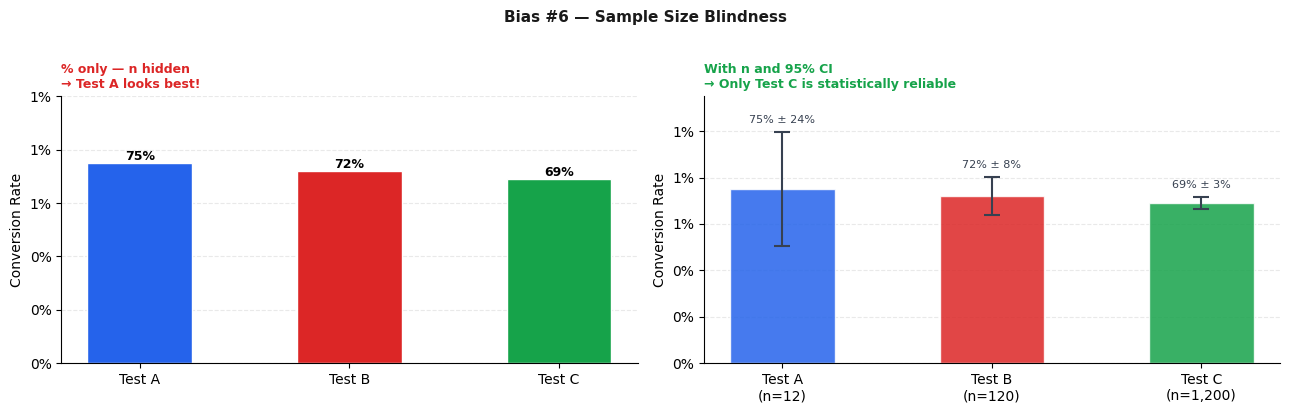

In [19]:
tests = {
    'Test A': {'pct': 0.75, 'n': 12},
    'Test B': {'pct': 0.72, 'n': 120},
    'Test C': {'pct': 0.69, 'n': 1200},
}

def ci_95(p, n):
    return 1.96 * np.sqrt(p * (1 - p) / n)

labels = list(tests.keys())
pcts   = [v['pct'] for v in tests.values()]
ns     = [v['n']   for v in tests.values()]
errors = [ci_95(p, n) for p, n in zip(pcts, ns)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='white')
colors3 = categorical_colors(3)

# Misleading: % only
ax = axes[0]
bars = ax.bar(range(3), pcts, color=colors3, width=0.5, edgecolor='white')
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel('Conversion Rate')
format_percent(ax, 'y', decimals=0)
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01, f'{p:.0%}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('% only — n hidden\n→ Test A looks best!',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Honest: % + n + CI
ax = axes[1]
bars = ax.bar(range(3), pcts, color=colors3, width=0.5, edgecolor='white',
              alpha=0.85, yerr=errors, capsize=6,
              error_kw=dict(ecolor='#374151', lw=1.5, capthick=1.5))
ax.set_xticks(range(3))
ax.set_xticklabels([f'{l}\n(n={n:,})' for l, n in zip(labels, ns)])
ax.set_ylim(0, 1.15); ax.set_ylabel('Conversion Rate')
format_percent(ax, 'y', decimals=0)
for i, (p, e) in enumerate(zip(pcts, errors)):
    ax.text(i, p + e + 0.04, f'{p:.0%} ± {e:.0%}',
            ha='center', fontsize=8, color='#374151')
ax.set_title('With n and 95% CI\n→ Only Test C is statistically reliable',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #6 — Sample Size Blindness',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Sample Size Blindness — Visualization Notes

Biểu đồ đặt **% only** cạnh **% + sample size + confidence interval**
để cho thấy việc ẩn n có thể gây hiểu nhầm.

### Percentage-only làm nhóm nhỏ trông tốt hơn
Chart bên trái chỉ hiển thị %:

- Test A cao nhất
- trông như winner
- không thấy độ tin cậy

n nhỏ không được thể hiện.

### Thêm n làm thay đổi interpretation
Chart bên phải hiển thị sample size:

- Test A n nhỏ
- Test C n lớn
- độ tin cậy khác nhau

Ranking theo độ tin cậy thay đổi.

### Error bars thể hiện uncertainty
Confidence interval:

- n nhỏ → CI rộng
- n lớn → CI hẹp
- overlap → không khác biệt đáng kể

Cho thấy mức độ chắc chắn.

### Cùng % nhưng ý nghĩa khác
Test A:

- % cao
- n nhỏ
- uncertainty lớn

Test C:

- % thấp hơn
- n lớn
- đáng tin hơn

Magnitude vs reliability.

### Label n giúp tránh bias
Hiển thị n:

- cung cấp context
- tránh over-interpretation
- cho thấy statistical power

Quan trọng với A/B test.

### % + n + CI là best practice
Hiển thị đầy đủ:

- bar = %
- label = n
- error bar = CI

Giúp đánh giá đúng significance.

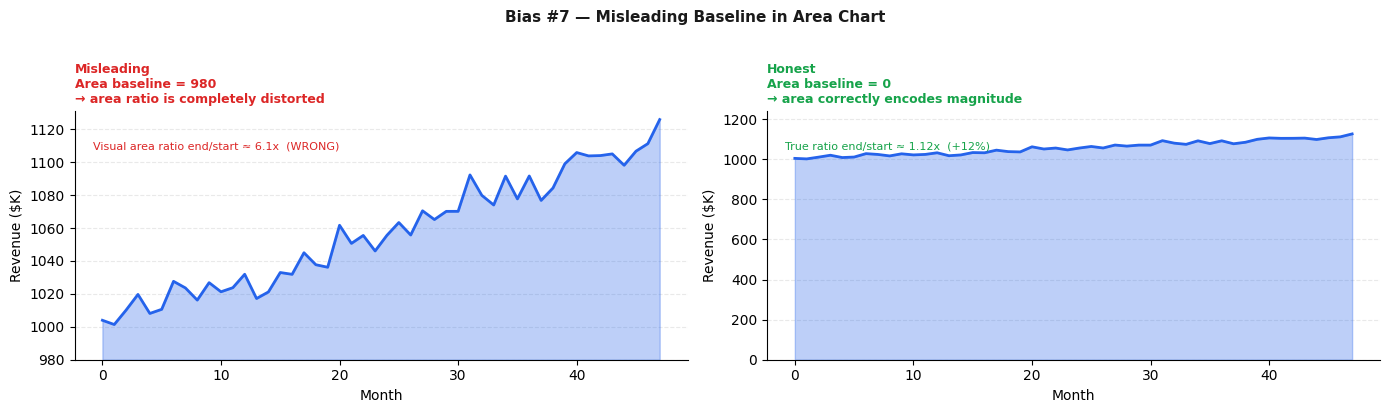

In [20]:
fig, axes = make_pair(
    'Area baseline = 980\n→ area ratio is completely distorted',
    'Area baseline = 0\n→ area correctly encodes magnitude'
)

v_start, v_end = revenue[0], revenue[-1]

# Misleading
ax = axes[0]
ax.fill_between(months, revenue, 980, color='#2563EB', alpha=0.3)
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(980, revenue.max() + 5)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
fake_ratio = (v_end - 980) / (v_start - 980)
add_note(ax, f'Visual area ratio end/start ≈ {fake_ratio:.1f}x  (WRONG)',
         x=0.03, y=0.88, color='#DC2626', fontsize=8)

# Honest
ax = axes[1]
ax.fill_between(months, revenue, 0, color='#2563EB', alpha=0.3)
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(0, revenue.max() * 1.1)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
true_ratio = v_end / v_start
add_note(ax, f'True ratio end/start ≈ {true_ratio:.2f}x  (+{(true_ratio-1)*100:.0f}%)',
         x=0.03, y=0.88, color='#16A34A', fontsize=8)

fig.suptitle('Bias #7 — Misleading Baseline in Area Chart',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Misleading Baseline — Area Chart Notes

Biểu đồ đặt **area chart baseline ≠ 0** cạnh **baseline = 0**
để cho thấy area chart dễ bị méo khi truncate.

### Truncated baseline làm diện tích bị phóng đại
Chart bên trái đặt baseline tại 980:

- vùng tô rất lớn
- chênh lệch nhỏ trông dramatic
- area ratio bị phóng đại

Area không còn tỷ lệ với value.

### Baseline = 0 giữ proportional area
Chart bên phải bắt đầu từ 0:

- diện tích phản ánh magnitude thật
- ratio giữa các điểm đúng
- growth trông modest

Encoding đúng với area chart.

### Area chart nhạy với baseline hơn line
Area encode:

- chiều cao
- diện tích

Baseline sai:

- cả hai đều bị méo
- distortion mạnh hơn line chart

### Cùng data nhưng visual ratio khác
Baseline ≠ 0:

- end/start area rất lớn
- exaggerate growth

Baseline = 0:

- ratio đúng với data
- growth nhỏ hơn

Narrative thay đổi theo baseline.

### Area chart phải bắt đầu từ zero
Area chart dùng để:

- encode magnitude
- so sánh area
- đọc proportional change

Baseline ≠ 0 phá vỡ proportional encoding.

## 8. Simpson's Paradox

Simpson's Paradox xảy ra khi **trend trong aggregate** bị đảo chiều
khi nhìn vào từng subgroup.

Cùng một dữ liệu nhưng:

- aggregate → kết luận A tốt hơn
- subgroup → B tốt hơn trong từng nhóm

Kết luận bị đảo ngược do composition.

---

### 8.1 Aggregate có thể che giấu subgroup structure

Aggregate data:

- gộp tất cả nhóm
- không thấy composition
- dễ kết luận sai

Subgroup breakdown:

- tách theo category
- thấy pattern thực
- phát hiện reversal

---

### 8.2 Confounding variable gây đảo chiều

Simpson's paradox xảy ra khi:

- các nhóm có baseline khác nhau
- phân bổ không đều giữa nhóm
- aggregate bị lệch theo composition

Trend aggregate phản ánh mix, không phải performance.

---

### 8.3 Ví dụ trực quan

Group A:

- Treatment tốt hơn control

Group B:

- Treatment cũng tốt hơn control

Nhưng:

- Treatment áp dụng nhiều ở group khó hơn
- Aggregate treatment thấp hơn control

Trend bị đảo chiều.

---

### 8.4 Composition effect

Aggregate phụ thuộc:

- subgroup size
- subgroup baseline
- distribution giữa nhóm

Thay đổi mix → thay đổi aggregate.

---

### 8.5 Cách phát hiện Simpson's paradox

Dấu hiệu:

- aggregate trend mạnh
- subgroup trend khác
- nhóm có size rất khác nhau
- baseline giữa nhóm khác biệt

Luôn kiểm tra breakdown.

---

### 8.6 Best practices

Để tránh Simpson's paradox:

- luôn plot subgroup
- hiển thị group size
- so sánh within-group
- annotate composition

Không chỉ nhìn aggregate.

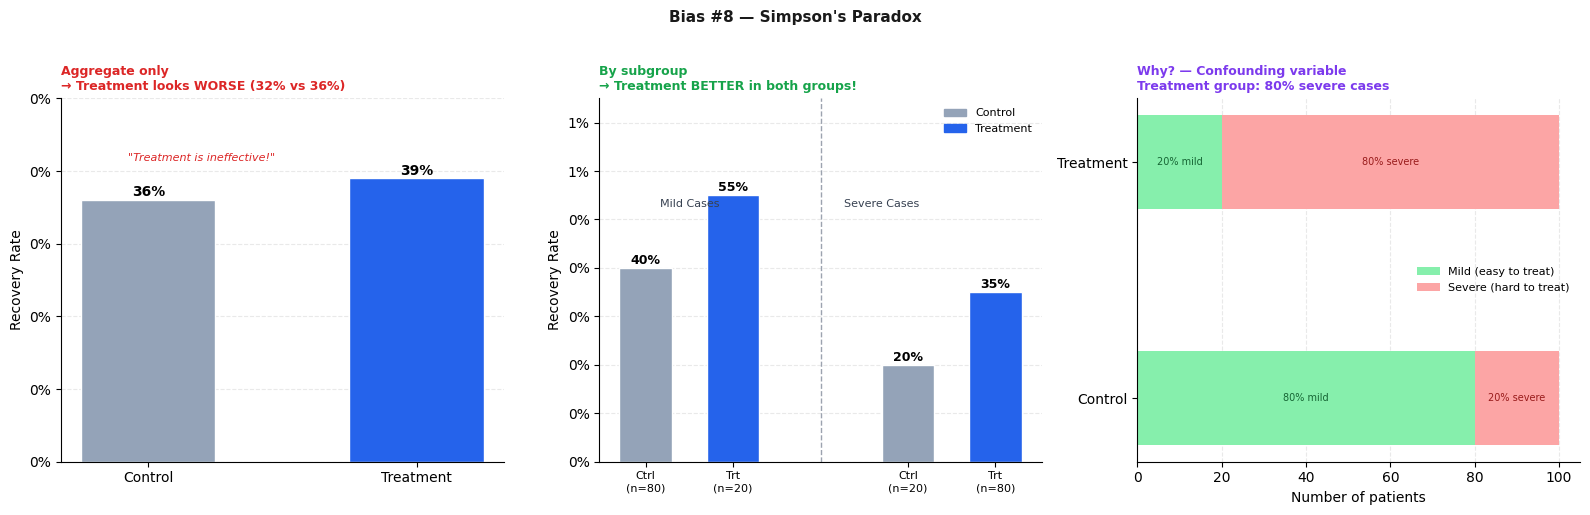

In [21]:
# Recovery rates
# Control : 80 mild (40%) + 20 severe (20%)
# Treatment: 20 mild (55%) + 80 severe (35%)
ctrl_mild_n,  ctrl_mild_r  = 80,  0.40
ctrl_sev_n,   ctrl_sev_r   = 20,  0.20
trt_mild_n,   trt_mild_r   = 20,  0.55
trt_sev_n,    trt_sev_r    = 80,  0.35

ctrl_overall = (ctrl_mild_n*ctrl_mild_r + ctrl_sev_n*ctrl_sev_r) / (ctrl_mild_n + ctrl_sev_n)
trt_overall  = (trt_mild_n *trt_mild_r  + trt_sev_n *trt_sev_r)  / (trt_mild_n  + trt_sev_n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

# Panel 1: Aggregate — treatment looks WORSE
ax = axes[0]
bars = ax.bar(['Control', 'Treatment'], [ctrl_overall, trt_overall],
              color=['#94A3B8', '#2563EB'], width=0.5, edgecolor='white')
for bar, v in zip(bars, [ctrl_overall, trt_overall]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{v:.0%}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 0.50); ax.set_ylabel('Recovery Rate')
format_percent(ax, 'y', decimals=0)
ax.set_title('Aggregate only\n→ Treatment looks WORSE (32% vs 36%)',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
add_note(ax, '"Treatment is ineffective!"',
         x=0.15, y=0.85, color='#DC2626', fontsize=8, style='italic')
despine(ax); set_grid(ax)

# Panel 2: By subgroup — treatment BETTER in both
ax = axes[1]
x     = np.array([0, 1, 3, 4])
rates = [ctrl_mild_r, trt_mild_r, ctrl_sev_r, trt_sev_r]
cols  = ['#94A3B8', '#2563EB', '#94A3B8', '#2563EB']
bars  = ax.bar(x, rates, color=cols, width=0.6, edgecolor='white')
for bar, v in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008, f'{v:.0%}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Ctrl\n(n=80)', 'Trt\n(n=20)',
                    'Ctrl\n(n=20)', 'Trt\n(n=80)'], fontsize=8)
ax.set_ylim(0, 0.75); ax.set_ylabel('Recovery Rate')
format_percent(ax, 'y', decimals=0)
ax.axvline(2, color='#9CA3AF', linewidth=1.0, linestyle='--')
ax.text(0.5, 0.70, 'Mild Cases', ha='center', fontsize=8, color='#374151',
        transform=ax.get_xaxis_transform())
ax.text(2.7, 0.70, 'Severe Cases', ha='center', fontsize=8, color='#374151',
        transform=ax.get_xaxis_transform())
ax.set_title('By subgroup\n→ Treatment BETTER in both groups!',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
ax.legend(handles=[
    mpatches.Patch(color='#94A3B8', label='Control'),
    mpatches.Patch(color='#2563EB', label='Treatment'),
], frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 3: Why — confounding (case mix)
ax = axes[2]
ax.barh(['Control', 'Treatment'], [ctrl_mild_n, trt_mild_n],
        color='#86EFAC', height=0.4, label='Mild (easy to treat)')
ax.barh(['Control', 'Treatment'], [ctrl_sev_n, trt_sev_n],
        left=[ctrl_mild_n, trt_mild_n],
        color='#FCA5A5', height=0.4, label='Severe (hard to treat)')
ax.set_xlabel('Number of patients')
ax.set_title('Why? — Confounding variable\nTreatment group: 80% severe cases',
             loc='left', fontsize=9, fontweight='bold', color='#7C3AED')
ax.legend(frameon=False, fontsize=8)
for i, (mild, sev) in enumerate([
    (ctrl_mild_n, ctrl_sev_n), (trt_mild_n, trt_sev_n)
]):
    total = mild + sev
    ax.text(mild/2, i, f'{mild/total:.0%} mild',
            ha='center', va='center', fontsize=7, color='#166534')
    ax.text(mild + sev/2, i, f'{sev/total:.0%} severe',
            ha='center', va='center', fontsize=7, color='#991B1B')
despine(ax); set_grid(ax, which='x')

fig.suptitle("Bias #8 — Simpson's Paradox",
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Simpson's Paradox — Visualization Notes

Ba panel cho thấy **aggregate**, **subgroup**, và **composition**
để minh họa Simpson's paradox.

### Aggregate-only đảo chiều kết luận
Chart bên trái gộp toàn bộ data:

- treatment thấp hơn control
- trông như treatment kém hơn
- kết luận sai lệch

Aggregate che giấu subgroup structure.

### Subgroup breakdown cho thấy trend thật
Chart giữa tách theo nhóm:

- mild: treatment tốt hơn
- severe: treatment cũng tốt hơn
- treatment thắng trong cả hai nhóm

Trend aggregate bị đảo chiều.

### Composition giải thích nghịch lý
Chart bên phải hiển thị phân bổ:

- treatment có nhiều case severe
- control có nhiều case mild
- baseline giữa nhóm khác nhau

Distribution gây bias aggregate.

### Confounding variable gây reversal
Severity là confounder:

- severe khó recover
- treatment áp dụng nhiều cho severe
- aggregate treatment thấp hơn

Không phải treatment kém.

### Aggregate phụ thuộc mix
Aggregate rate bị ảnh hưởng bởi:

- group size
- baseline từng nhóm
- distribution giữa nhóm

Thay đổi mix → đảo chiều kết luận.

### Breakdown tránh Simpson's paradox
Hiển thị:

- subgroup performance
- group size
- composition

Giúp hiểu trend thật.

---
## 9. Honest Chart Checklist

Chạy qua checklist này trước khi publish bất kỳ chart nào.

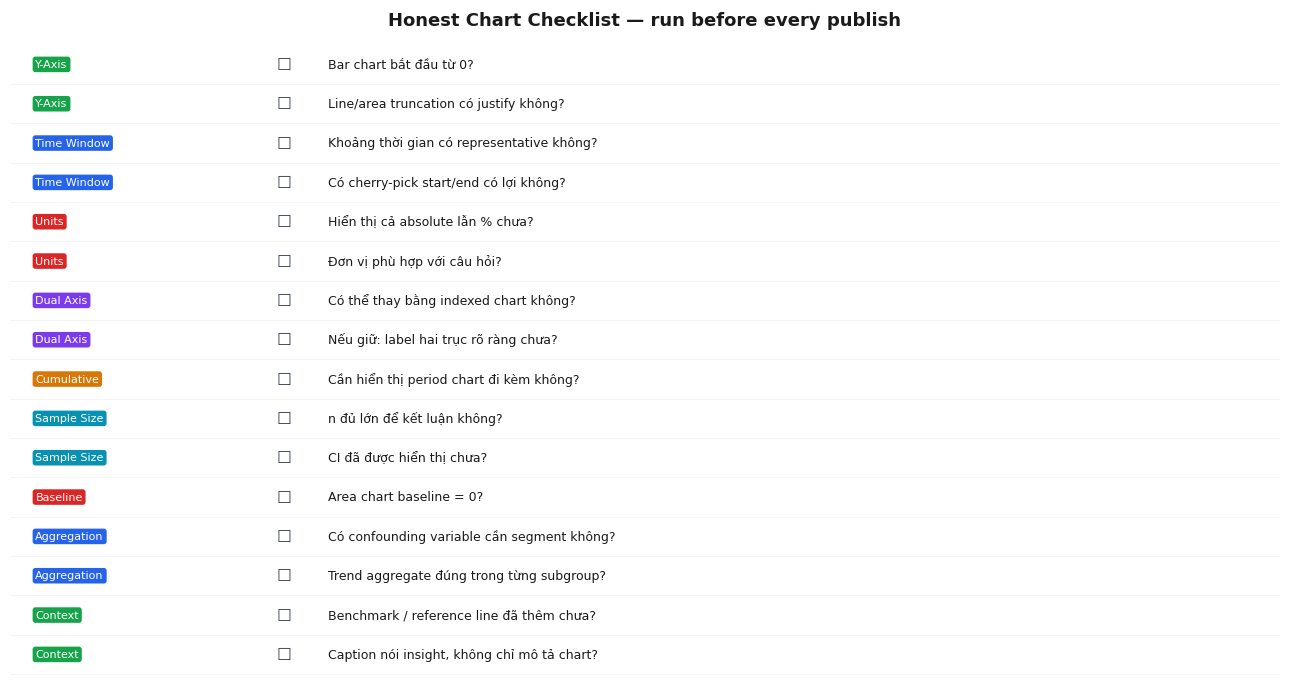

In [24]:
checklist = [
    ('Y-Axis',       'Bar chart bắt đầu từ 0?'),
    ('Y-Axis',       'Line/area truncation có justify không?'),
    ('Time Window',  'Khoảng thời gian có representative không?'),
    ('Time Window',  'Có cherry-pick start/end có lợi không?'),
    ('Units',        'Hiển thị cả absolute lẫn % chưa?'),
    ('Units',        'Đơn vị phù hợp với câu hỏi?'),
    ('Dual Axis',    'Có thể thay bằng indexed chart không?'),
    ('Dual Axis',    'Nếu giữ: label hai trục rõ ràng chưa?'),
    ('Cumulative',   'Cần hiển thị period chart đi kèm không?'),
    ('Sample Size',  'n đủ lớn để kết luận không?'),
    ('Sample Size',  'CI đã được hiển thị chưa?'),
    ('Baseline',     'Area chart baseline = 0?'),
    ('Aggregation',  'Có confounding variable cần segment không?'),
    ('Aggregation',  'Trend aggregate đúng trong từng subgroup?'),
    ('Context',      'Benchmark / reference line đã thêm chưa?'),
    ('Context',      'Caption nói insight, không chỉ mô tả chart?'),
]

fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')

ax.set_xlim(0, 10)
ax.set_ylim(0, len(checklist) + 1)
ax.axis('off')

categories = sorted(set(c for c, _ in checklist))
cat_colors = dict(zip(categories, categorical_colors(len(categories))))

ax.text(
    5,
    len(checklist) + 0.6,
    'Honest Chart Checklist — run before every publish',
    ha='center',
    fontsize=13,
    fontweight='bold',
    color='#1a1a1a'
)

for i, (cat, question) in enumerate(reversed(checklist)):
    y = i + 0.6
    color = cat_colors[cat]

    # category tag
    ax.text(
        0.2,
        y,
        cat,
        fontsize=8,
        color='white',
        va='center',
        bbox=dict(
            boxstyle='round,pad=0.25',
            fc=color,
            ec='none'
        )
    )

    # checkbox
    ax.text(
        2.1,
        y,
        '☐',
        fontsize=12,
        va='center',
        color='#374151'
    )

    # text
    ax.text(
        2.5,
        y,
        question,
        fontsize=9,
        va='center',
        color='#1a1a1a'
    )

    # separator
    ax.axhline(
        i + 0.1,
        color='#f3f4f6',
        linewidth=0.8
    )

plt.tight_layout()
plt.show()

---
## Summary

| Bias | Kỹ thuật | Cách nhận ra |
|------|----------|--------------|
| Truncated Y-Axis | Y không từ 0 | Bar chart trông thay đổi lớn nhưng số nhỏ |
| Cherry-picking | Window có lợi | Hỏi: trước và sau khoảng này là gì? |
| % vs Absolute | Chỉ một đơn vị | Hỏi: n là bao nhiêu? Base là bao nhiêu? |
| Dual axis | Scale độc lập | Hai series trông perfectly correlated |
| Cumulative | Ẩn period âm | Chart chỉ đi lên dù growth chậm |
| Sample size | % không có n | Không có CI, không có n trên chart |
| Misleading baseline | Area không từ 0 | Fill không bắt đầu từ đáy |
| Simpson's paradox | Chỉ aggregate | Hỏi: có subgroup quan trọng nào không? |

---

### Key Takeaway

> Misleading visualization thường không phải là **nói dối** — nó là **nói sự thật một phần**.
> Số liệu có thể chính xác 100% nhưng chart vẫn mislead nếu context bị ẩn đi.
>
> Người tạo chart có trách nhiệm chủ động cung cấp context —
> baseline, sample size, time window đầy đủ, subgroup breakdown —
> ngay cả khi không ai yêu cầu.

**Next →** `08_visualization_storytelling.ipynb` — Kết hợp tất cả: từ raw data đến một câu chuyện hoàn chỉnh.